In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print('All libraries imported successfully!')

All libraries imported successfully!


In [2]:
df = pd.read_csv(r'C:\Users\Gohar\Desktop\DASS_Complete.csv')

# Anxiety questions only
anxiety_cols = [
    'Q2 (A)', 'Q4 (A)', 'Q7 (A)', 'Q9 (A)', 'Q15 (A)', 'Q19 (A)',
    'Q20 (A)', 'Q23 (A)', 'Q25 (A)', 'Q28 (A)', 'Q30 (A)', 'Q36 (A)',
    'Q40 (A)', 'Q41 (A)'
]

# Replace FALSE with Normal
df['Anxiety Severity'] = df['Anxiety Severity'].replace('FALSE', 'Normal')

X_all = df[anxiety_cols].copy()
y     = df['Anxiety Severity'].copy()

print('Dataset Shape   :', df.shape)
print('Features Shape  :', X_all.shape)
print('Missing Values  :', X_all.isnull().sum().sum())
print('\nClass Distribution:')
print(y.value_counts())
df.head()

Dataset Shape   : (39775, 49)
Features Shape  : (39775, 14)
Missing Values  : 0

Class Distribution:
Anxiety Severity
Extremely Severe    32885
Severe               5020
Normal                956
Moderate              914
Name: count, dtype: int64


,ID,Q1 (S),Q2 (A),Q3 (D),Q4 (A),Q5 (D),Q6 (S),Q7 (A),Q8 (S),Q9 (A),...,Q39 (S),Q40 (A),Q41 (A),Q42 (D),Depression Score,Depression Severity,Anxiety Score,Anxiety Severity,Stress Score,Stress Severity
0,1,4,4,2,4,4,4,4,4,2,...,4,3,4,4,41,Extremely Severe,48,Extremely Severe,54,Extremely Severe
1,2,4,1,2,3,4,4,3,4,3,...,2,1,2,2,38,Extremely Severe,31,Extremely Severe,41,Extremely Severe
2,3,3,1,4,1,4,3,1,3,2,...,2,2,1,4,53,Extremely Severe,26,Extremely Severe,31,Severe
3,4,2,3,2,1,3,3,4,2,3,...,3,4,4,2,30,Extremely Severe,31,Extremely Severe,30,Severe
4,5,2,2,3,4,4,2,4,4,4,...,3,4,4,3,46,Extremely Severe,54,Extremely Severe,43,Extremely Severe


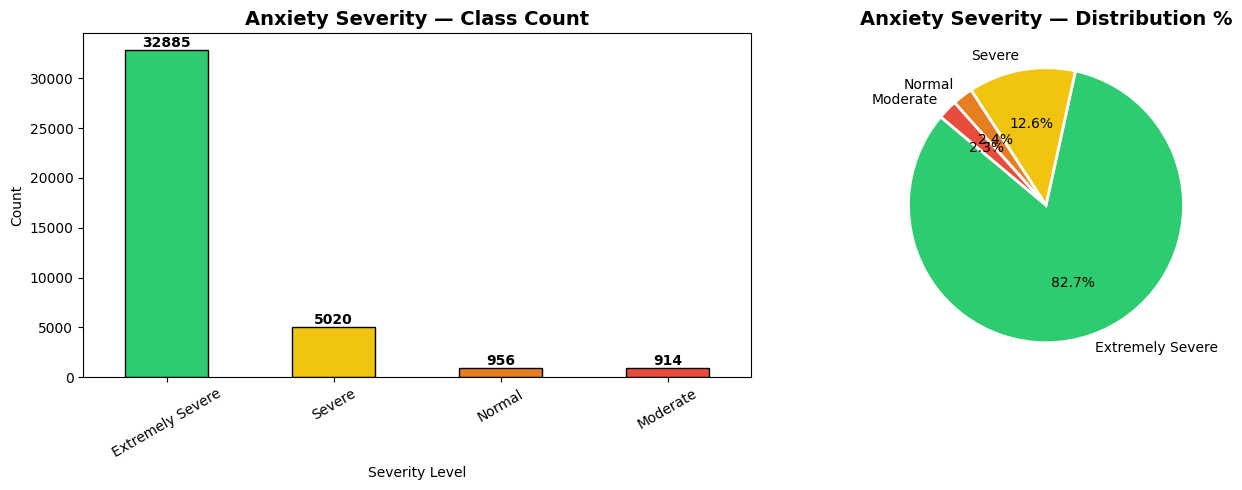

In [3]:
colors4 = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = y.value_counts()
counts.plot(kind='bar', ax=axes[0], color=colors4, edgecolor='black')
axes[0].set_title('Anxiety Severity — Class Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Severity Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=colors4,
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Anxiety Severity — Distribution %', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

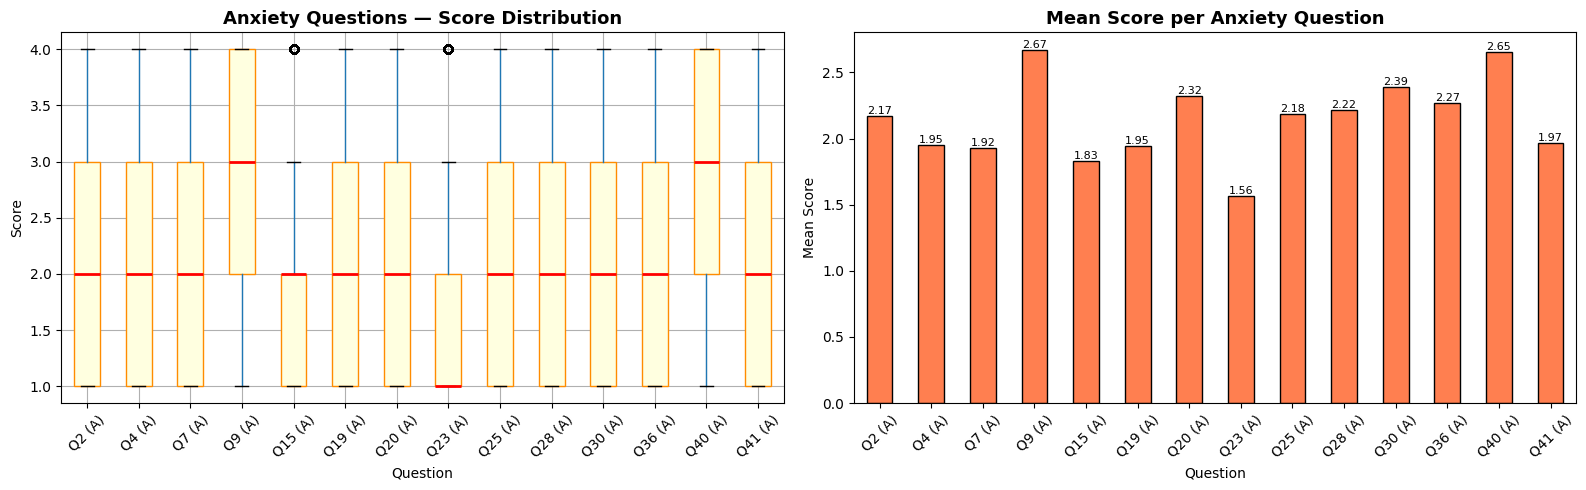

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

X_all.boxplot(ax=axes[0], patch_artist=True,
              boxprops=dict(facecolor='lightyellow', color='darkorange'),
              medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Anxiety Questions — Score Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Question')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=45)

X_all.mean().plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Mean Score per Anxiety Question', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Question')
axes[1].set_ylabel('Mean Score')
axes[1].tick_params(axis='x', rotation=45)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

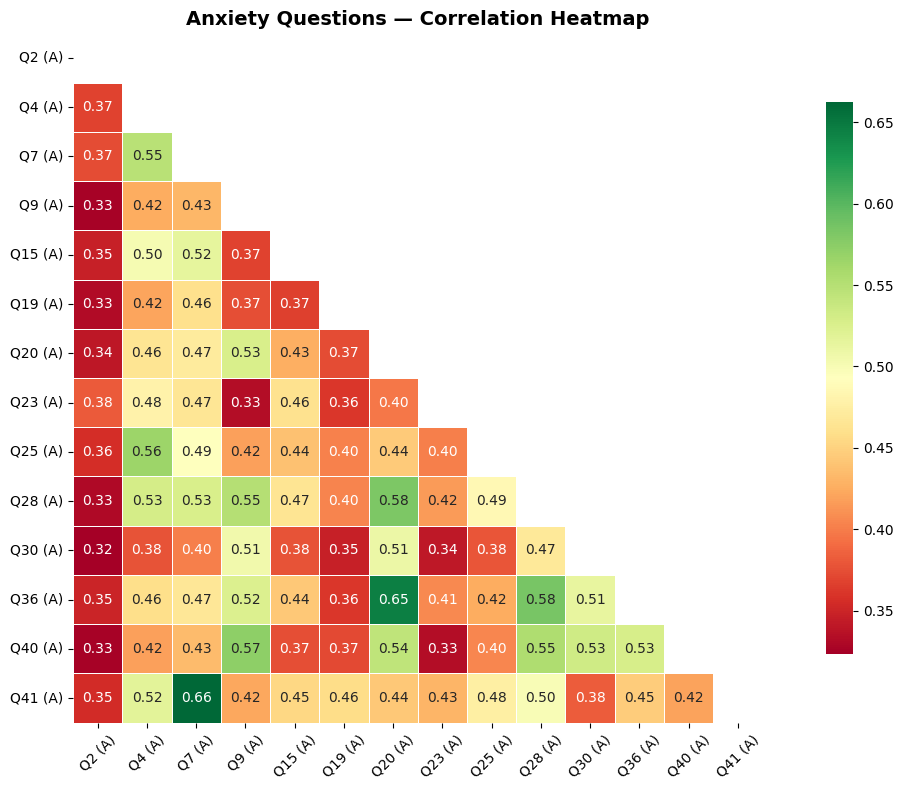

In [5]:
plt.figure(figsize=(13, 8))
corr = X_all.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Anxiety Questions — Correlation Heatmap', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print('Label Encoding:')
for i, cls in enumerate(le.classes_):
    print(f'  {i}  ->  {cls}')

X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f'\nTrain size : {X_train_all.shape[0]}')
print(f'Test size  : {X_test_all.shape[0]}')

Label Encoding:
  0  ->  Extremely Severe
  1  ->  Moderate
  2  ->  Normal
  3  ->  Severe

Train size : 31820
Test size  : 7955


In [7]:
def train_evaluate(model, X_tr, X_te, y_tr, y_te, model_name, round_label, cmap='Blues'):
    """Train model, print classification report, plot confusion matrix."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)

    print('=' * 55)
    print(f'  {model_name}  |  {round_label}')
    print('=' * 55)
    print(f'  Accuracy : {acc*100:.2f}%')
    print('-' * 55)
    print(classification_report(y_te, y_pred, target_names=le.classes_))

    cm   = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    fig, ax = plt.subplots(figsize=(8, 5))
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f'{model_name} | {round_label} | Acc: {acc*100:.2f}%',
                 fontsize=12, fontweight='bold')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    return acc, model.feature_importances_


def plot_feature_importance(importances, feature_names, model_name, round_label, color='coral'):
    """Plot feature importances bar chart. Returns features sorted by importance (desc)."""
    feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feat_df = feat_df.sort_values('Importance', ascending=False).reset_index(drop=True)

    plt.figure(figsize=(10, 5))
    plt.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1],
             color=color, edgecolor='black')
    plt.title(f'{model_name} | {round_label} — Feature Importance',
              fontsize=13, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    return feat_df['Feature'].tolist()


print('Helper functions ready!')

Helper functions ready!


  Random Forest  |  Round 1 — All 14 Questions
  Accuracy : 98.57%
-------------------------------------------------------
                  precision    recall  f1-score   support

Extremely Severe       0.99      0.99      0.99      6577
        Moderate       1.00      1.00      1.00       183
          Normal       0.99      1.00      0.99       191
          Severe       0.94      0.94      0.94      1004

        accuracy                           0.99      7955
       macro avg       0.98      0.98      0.98      7955
    weighted avg       0.99      0.99      0.99      7955



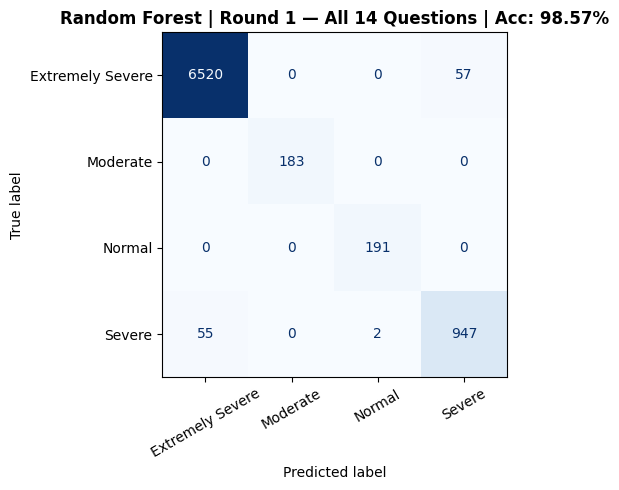

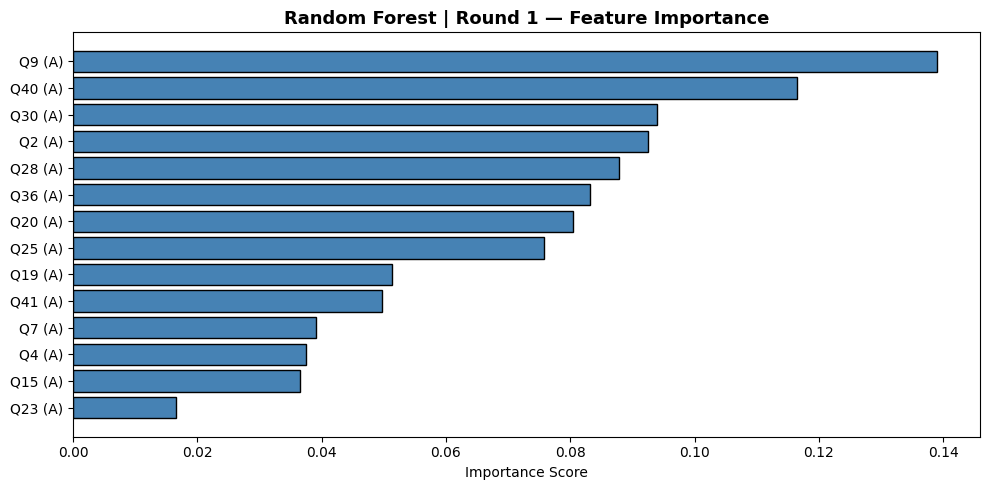

Top 8 for Round 2: ['Q9 (A)', 'Q40 (A)', 'Q30 (A)', 'Q2 (A)', 'Q28 (A)', 'Q36 (A)', 'Q20 (A)', 'Q25 (A)']
Top 3 for Round 3: ['Q9 (A)', 'Q40 (A)', 'Q30 (A)']


In [8]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                             random_state=42, n_jobs=-1)

acc_rf_r1, imp_rf = train_evaluate(
    rf, X_train_all, X_test_all, y_train, y_test,
    model_name='Random Forest', round_label='Round 1 — All 14 Questions', cmap='Blues'
)

rf_sorted = plot_feature_importance(
    imp_rf, anxiety_cols, 'Random Forest', 'Round 1', color='steelblue'
)

rf_top8 = rf_sorted[:8]
rf_top3 = rf_sorted[:3]

print('Top 8 for Round 2:', rf_top8)
print('Top 3 for Round 3:', rf_top3)

  Random Forest  |  Round 2 — Top 8 Questions
  Accuracy : 92.99%
-------------------------------------------------------
                  precision    recall  f1-score   support

Extremely Severe       0.99      0.95      0.97      6577
        Moderate       0.75      1.00      0.86       183
          Normal       0.62      0.79      0.69       191
          Severe       0.71      0.83      0.77      1004

        accuracy                           0.93      7955
       macro avg       0.77      0.89      0.82      7955
    weighted avg       0.94      0.93      0.93      7955



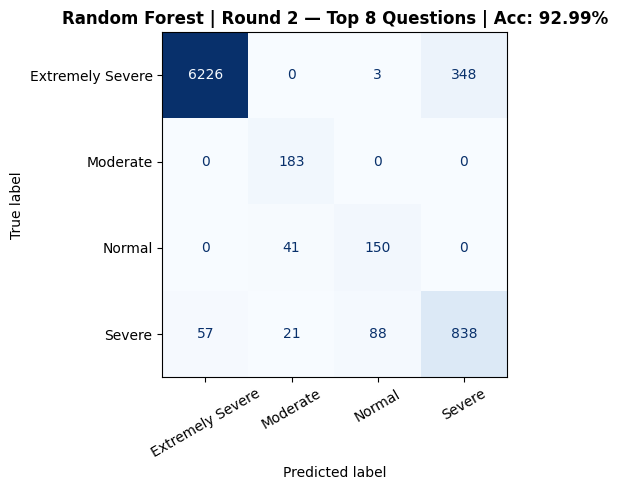

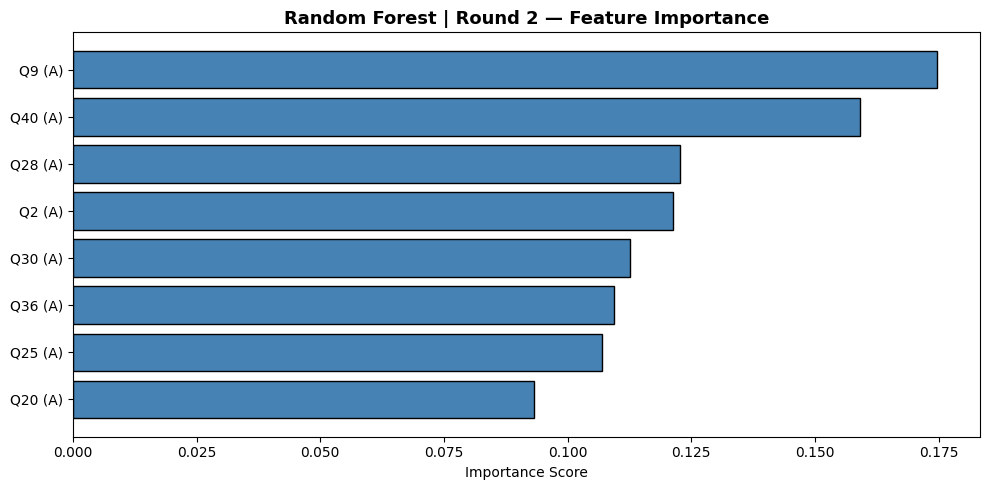

Round 1 Accuracy : 98.57%
Round 2 Accuracy : 92.99%


In [9]:
X_train_rf8 = X_train_all[rf_top8]
X_test_rf8  = X_test_all[rf_top8]

rf2 = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                              random_state=42, n_jobs=-1)

acc_rf_r2, imp_rf2 = train_evaluate(
    rf2, X_train_rf8, X_test_rf8, y_train, y_test,
    model_name='Random Forest', round_label='Round 2 — Top 8 Questions', cmap='Blues'
)

plot_feature_importance(imp_rf2, rf_top8, 'Random Forest', 'Round 2', color='steelblue')

print(f'Round 1 Accuracy : {acc_rf_r1*100:.2f}%')
print(f'Round 2 Accuracy : {acc_rf_r2*100:.2f}%')

  Random Forest  |  Round 3 — Top 3 Questions
  Accuracy : 73.39%
-------------------------------------------------------
                  precision    recall  f1-score   support

Extremely Severe       0.99      0.78      0.87      6577
        Moderate       0.34      1.00      0.50       183
          Normal       0.14      0.43      0.21       191
          Severe       0.27      0.44      0.33      1004

        accuracy                           0.73      7955
       macro avg       0.43      0.66      0.48      7955
    weighted avg       0.86      0.73      0.78      7955



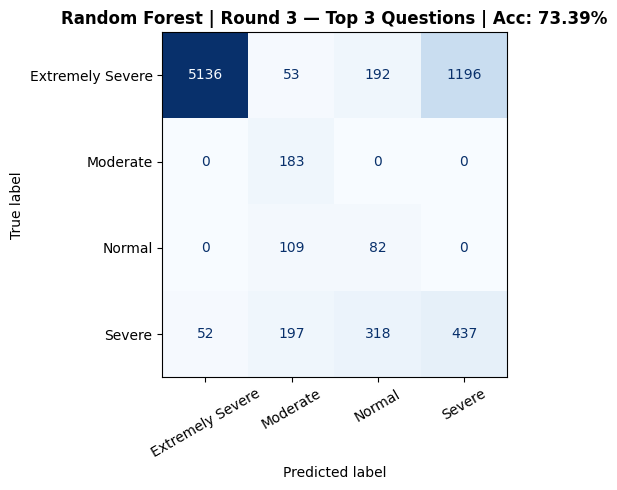

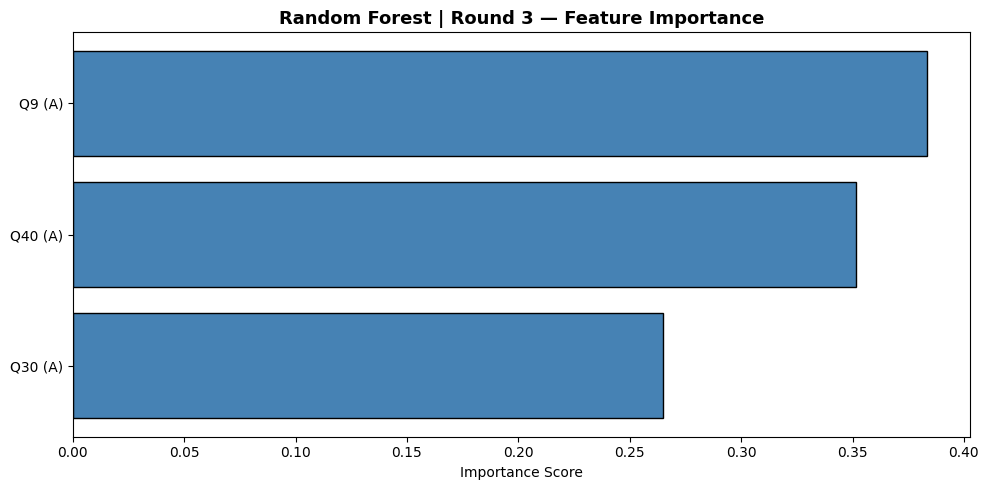

   RANDOM FOREST — ROUNDS SUMMARY
  Round 1 (14 Questions) : 98.57%
  Round 2 (Top 8)        : 92.99%
  Round 3 (Top 3)        : 73.39%
  Best RF Accuracy       : 98.57%


In [10]:
X_train_rf3 = X_train_all[rf_top3]
X_test_rf3  = X_test_all[rf_top3]

rf3 = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                              random_state=42, n_jobs=-1)

acc_rf_r3, imp_rf3 = train_evaluate(
    rf3, X_train_rf3, X_test_rf3, y_train, y_test,
    model_name='Random Forest', round_label='Round 3 — Top 3 Questions', cmap='Blues'
)

plot_feature_importance(imp_rf3, rf_top3, 'Random Forest', 'Round 3', color='steelblue')

print('=' * 45)
print('   RANDOM FOREST — ROUNDS SUMMARY')
print('=' * 45)
print(f'  Round 1 (14 Questions) : {acc_rf_r1*100:.2f}%')
print(f'  Round 2 (Top 8)        : {acc_rf_r2*100:.2f}%')
print(f'  Round 3 (Top 3)        : {acc_rf_r3*100:.2f}%')
print(f'  Best RF Accuracy       : {max(acc_rf_r1, acc_rf_r2, acc_rf_r3)*100:.2f}%')

  XGBoost  |  Round 1 — All 14 Questions
  Accuracy : 98.92%
-------------------------------------------------------
                  precision    recall  f1-score   support

Extremely Severe       0.99      1.00      1.00      6577
        Moderate       0.98      1.00      0.99       183
          Normal       0.96      0.92      0.94       191
          Severe       0.97      0.95      0.96      1004

        accuracy                           0.99      7955
       macro avg       0.98      0.97      0.97      7955
    weighted avg       0.99      0.99      0.99      7955



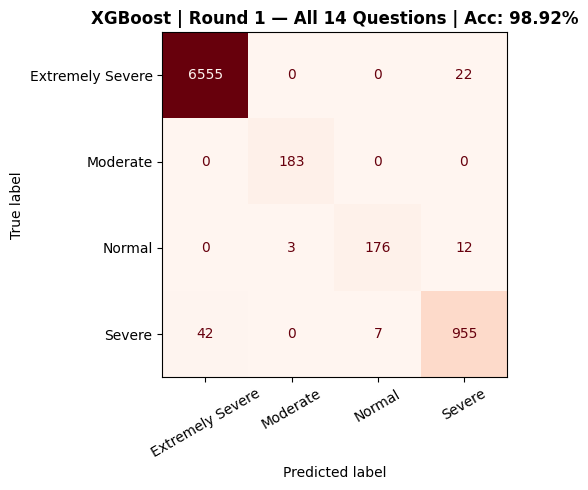

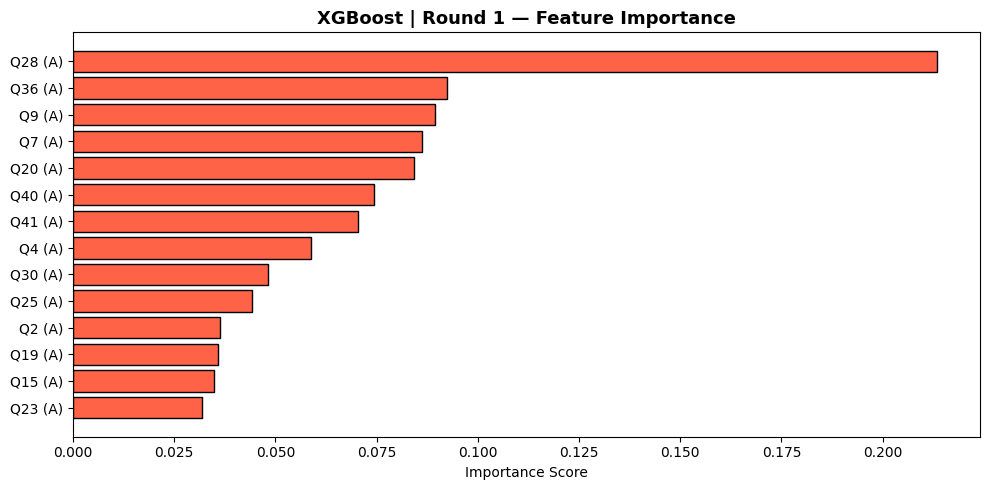

Top 8 for Round 2: ['Q28 (A)', 'Q36 (A)', 'Q9 (A)', 'Q7 (A)', 'Q20 (A)', 'Q40 (A)', 'Q41 (A)', 'Q4 (A)']
Top 3 for Round 3: ['Q28 (A)', 'Q36 (A)', 'Q9 (A)']


In [11]:
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                    eval_metric='mlogloss', random_state=42, n_jobs=-1)

acc_xgb_r1, imp_xgb = train_evaluate(
    xgb, X_train_all, X_test_all, y_train, y_test,
    model_name='XGBoost', round_label='Round 1 — All 14 Questions', cmap='Reds'
)

xgb_sorted = plot_feature_importance(
    imp_xgb, anxiety_cols, 'XGBoost', 'Round 1', color='tomato'
)

xgb_top8 = xgb_sorted[:8]
xgb_top3 = xgb_sorted[:3]

print('Top 8 for Round 2:', xgb_top8)
print('Top 3 for Round 3:', xgb_top3)

  XGBoost  |  Round 2 — Top 8 Questions
  Accuracy : 91.54%
-------------------------------------------------------
                  precision    recall  f1-score   support

Extremely Severe       0.97      0.97      0.97      6577
        Moderate       0.50      1.00      0.66       183
          Normal       0.00      0.00      0.00       191
          Severe       0.70      0.74      0.72      1004

        accuracy                           0.92      7955
       macro avg       0.54      0.68      0.59      7955
    weighted avg       0.90      0.92      0.91      7955



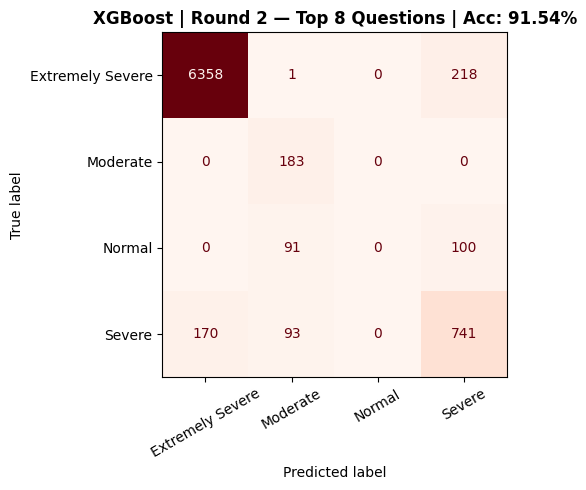

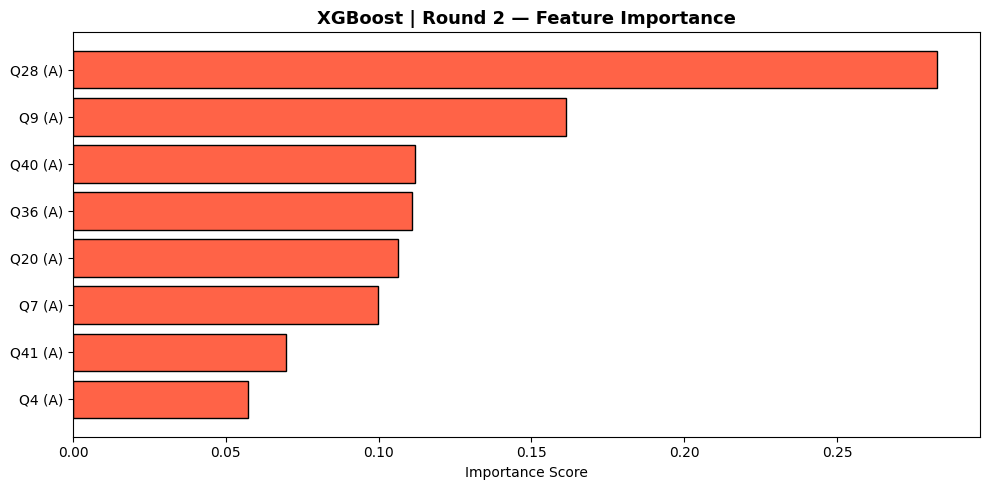

Round 1 Accuracy : 98.92%
Round 2 Accuracy : 91.54%


In [12]:
X_train_xgb8 = X_train_all[xgb_top8]
X_test_xgb8  = X_test_all[xgb_top8]

xgb2 = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                     eval_metric='mlogloss', random_state=42, n_jobs=-1)

acc_xgb_r2, imp_xgb2 = train_evaluate(
    xgb2, X_train_xgb8, X_test_xgb8, y_train, y_test,
    model_name='XGBoost', round_label='Round 2 — Top 8 Questions', cmap='Reds'
)

plot_feature_importance(imp_xgb2, xgb_top8, 'XGBoost', 'Round 2', color='tomato')

print(f'Round 1 Accuracy : {acc_xgb_r1*100:.2f}%')
print(f'Round 2 Accuracy : {acc_xgb_r2*100:.2f}%')

  XGBoost  |  Round 3 — Top 3 Questions
  Accuracy : 85.86%
-------------------------------------------------------
                  precision    recall  f1-score   support

Extremely Severe       0.94      0.94      0.94      6577
        Moderate       0.00      0.00      0.00       183
          Normal       0.00      0.00      0.00       191
          Severe       0.46      0.63      0.53      1004

        accuracy                           0.86      7955
       macro avg       0.35      0.39      0.37      7955
    weighted avg       0.84      0.86      0.85      7955



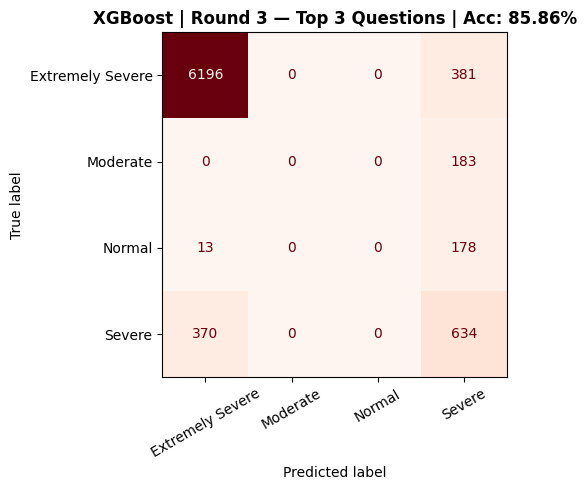

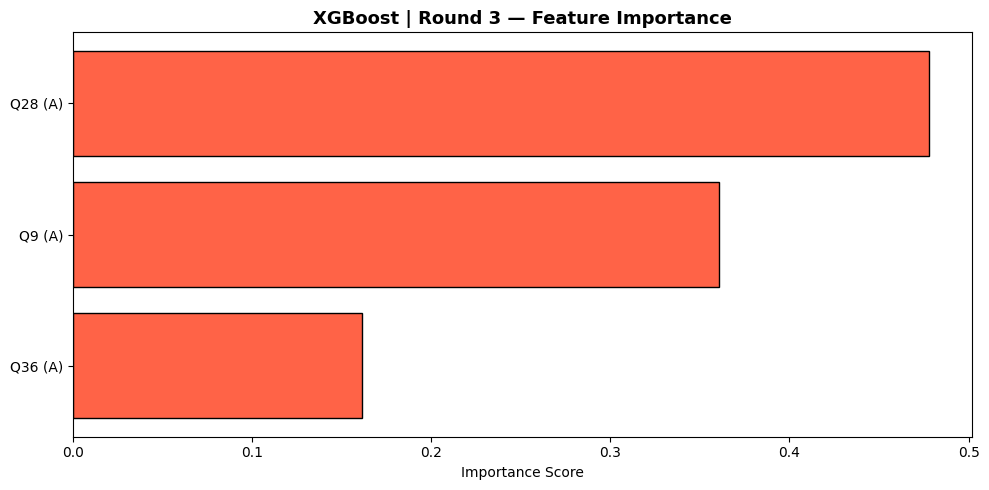

      XGBOOST — ROUNDS SUMMARY
  Round 1 (14 Questions) : 98.92%
  Round 2 (Top 8)        : 91.54%
  Round 3 (Top 3)        : 85.86%
  Best XGBoost Accuracy  : 98.92%


In [13]:
X_train_xgb3 = X_train_all[xgb_top3]
X_test_xgb3  = X_test_all[xgb_top3]

xgb3 = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                     eval_metric='mlogloss', random_state=42, n_jobs=-1)

acc_xgb_r3, imp_xgb3 = train_evaluate(
    xgb3, X_train_xgb3, X_test_xgb3, y_train, y_test,
    model_name='XGBoost', round_label='Round 3 — Top 3 Questions', cmap='Reds'
)

plot_feature_importance(imp_xgb3, xgb_top3, 'XGBoost', 'Round 3', color='tomato')

print('=' * 45)
print('      XGBOOST — ROUNDS SUMMARY')
print('=' * 45)
print(f'  Round 1 (14 Questions) : {acc_xgb_r1*100:.2f}%')
print(f'  Round 2 (Top 8)        : {acc_xgb_r2*100:.2f}%')
print(f'  Round 3 (Top 3)        : {acc_xgb_r3*100:.2f}%')
print(f'  Best XGBoost Accuracy  : {max(acc_xgb_r1, acc_xgb_r2, acc_xgb_r3)*100:.2f}%')

  LightGBM  |  Round 1 — All 14 Questions
  Accuracy : 97.85%
-------------------------------------------------------
                  precision    recall  f1-score   support

Extremely Severe       1.00      0.98      0.99      6577
        Moderate       1.00      1.00      1.00       183
          Normal       0.88      1.00      0.93       191
          Severe       0.87      0.97      0.92      1004

        accuracy                           0.98      7955
       macro avg       0.94      0.99      0.96      7955
    weighted avg       0.98      0.98      0.98      7955



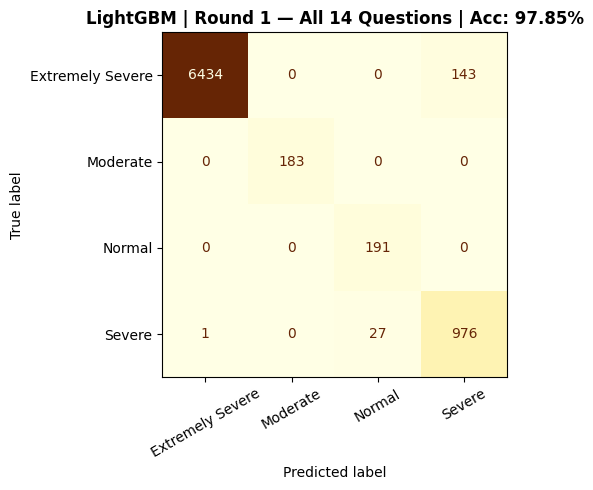

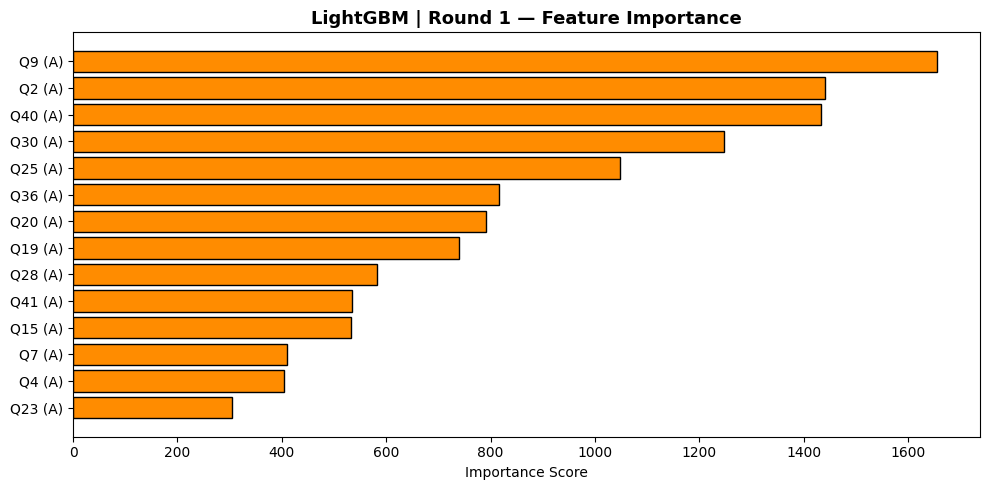

Top 8 for Round 2: ['Q9 (A)', 'Q2 (A)', 'Q40 (A)', 'Q30 (A)', 'Q25 (A)', 'Q36 (A)', 'Q20 (A)', 'Q19 (A)']
Top 3 for Round 3: ['Q9 (A)', 'Q2 (A)', 'Q40 (A)']


In [14]:
lgbm = LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                      class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)

acc_lgbm_r1, imp_lgbm = train_evaluate(
    lgbm, X_train_all, X_test_all, y_train, y_test,
    model_name='LightGBM', round_label='Round 1 — All 14 Questions', cmap='YlOrBr'
)

lgbm_sorted = plot_feature_importance(
    imp_lgbm, anxiety_cols, 'LightGBM', 'Round 1', color='darkorange'
)

lgbm_top8 = lgbm_sorted[:8]
lgbm_top3 = lgbm_sorted[:3]

print('Top 8 for Round 2:', lgbm_top8)
print('Top 3 for Round 3:', lgbm_top3)

  LightGBM  |  Round 2 — Top 8 Questions
  Accuracy : 92.97%
-------------------------------------------------------
                  precision    recall  f1-score   support

Extremely Severe       0.99      0.94      0.97      6577
        Moderate       0.79      1.00      0.88       183
          Normal       0.64      0.83      0.72       191
          Severe       0.69      0.86      0.77      1004

        accuracy                           0.93      7955
       macro avg       0.78      0.91      0.84      7955
    weighted avg       0.94      0.93      0.93      7955



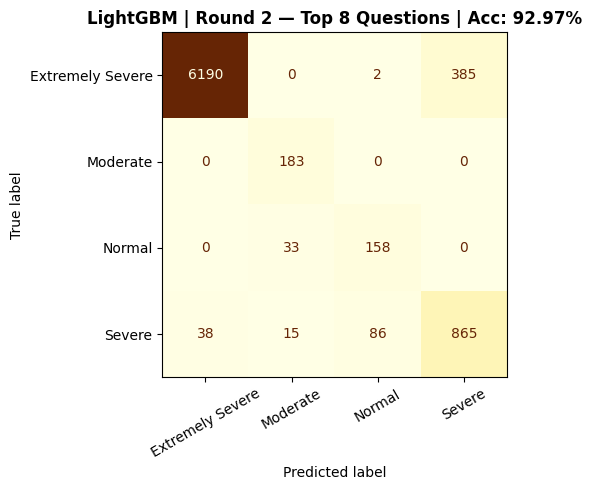

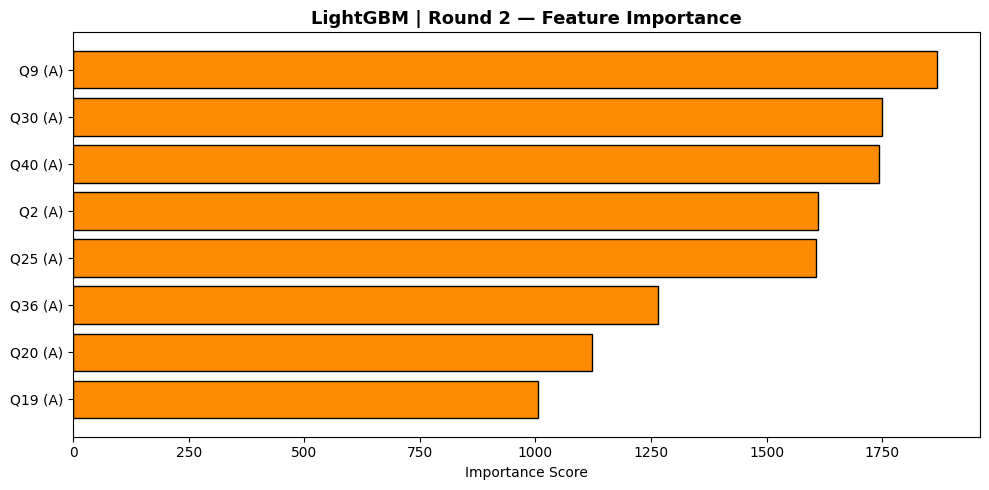

Round 1 Accuracy : 97.85%
Round 2 Accuracy : 92.97%


In [15]:
X_train_lgbm8 = X_train_all[lgbm_top8]
X_test_lgbm8  = X_test_all[lgbm_top8]

lgbm2 = LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                       class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)

acc_lgbm_r2, imp_lgbm2 = train_evaluate(
    lgbm2, X_train_lgbm8, X_test_lgbm8, y_train, y_test,
    model_name='LightGBM', round_label='Round 2 — Top 8 Questions', cmap='YlOrBr'
)

plot_feature_importance(imp_lgbm2, lgbm_top8, 'LightGBM', 'Round 2', color='darkorange')

print(f'Round 1 Accuracy : {acc_lgbm_r1*100:.2f}%')
print(f'Round 2 Accuracy : {acc_lgbm_r2*100:.2f}%')

  LightGBM  |  Round 3 — Top 3 Questions
  Accuracy : 79.84%
-------------------------------------------------------
                  precision    recall  f1-score   support

Extremely Severe       0.98      0.87      0.92      6577
        Moderate       0.38      1.00      0.55       183
          Normal       0.13      0.42      0.19       191
          Severe       0.37      0.36      0.37      1004

        accuracy                           0.80      7955
       macro avg       0.46      0.66      0.51      7955
    weighted avg       0.87      0.80      0.83      7955



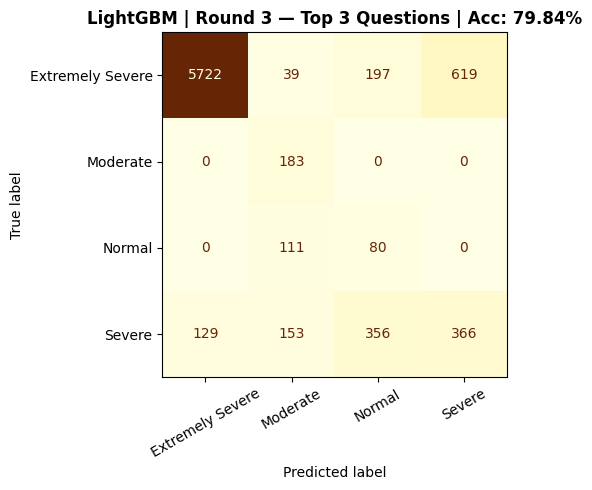

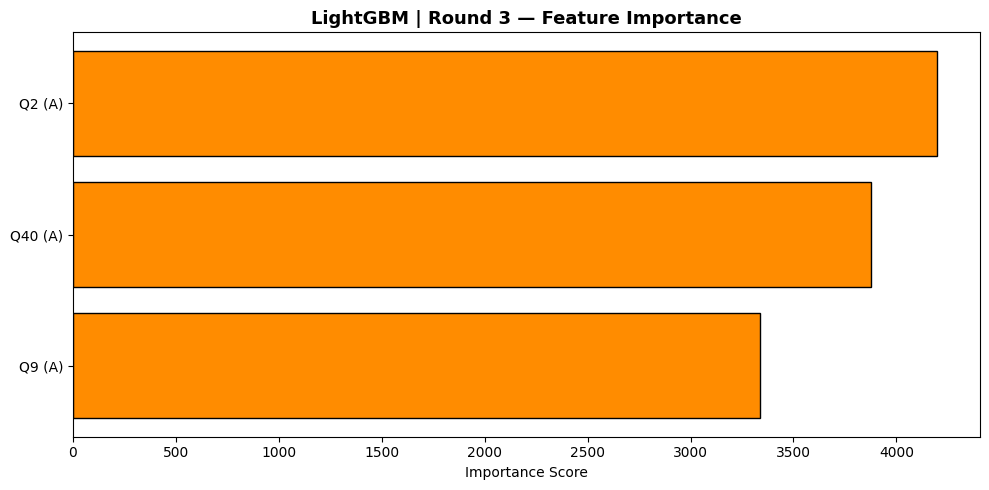

     LIGHTGBM — ROUNDS SUMMARY
  Round 1 (14 Questions) : 97.85%
  Round 2 (Top 8)        : 92.97%
  Round 3 (Top 3)        : 79.84%
  Best LightGBM Accuracy : 97.85%


In [16]:
X_train_lgbm3 = X_train_all[lgbm_top3]
X_test_lgbm3  = X_test_all[lgbm_top3]

lgbm3 = LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                       class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)

acc_lgbm_r3, imp_lgbm3 = train_evaluate(
    lgbm3, X_train_lgbm3, X_test_lgbm3, y_train, y_test,
    model_name='LightGBM', round_label='Round 3 — Top 3 Questions', cmap='YlOrBr'
)

plot_feature_importance(imp_lgbm3, lgbm_top3, 'LightGBM', 'Round 3', color='darkorange')

print('=' * 45)
print('     LIGHTGBM — ROUNDS SUMMARY')
print('=' * 45)
print(f'  Round 1 (14 Questions) : {acc_lgbm_r1*100:.2f}%')
print(f'  Round 2 (Top 8)        : {acc_lgbm_r2*100:.2f}%')
print(f'  Round 3 (Top 3)        : {acc_lgbm_r3*100:.2f}%')
print(f'  Best LightGBM Accuracy : {max(acc_lgbm_r1, acc_lgbm_r2, acc_lgbm_r3)*100:.2f}%')

In [17]:
summary = {
    'Model' : ['Random Forest', 'Random Forest', 'Random Forest',
               'XGBoost',       'XGBoost',       'XGBoost',
               'LightGBM',      'LightGBM',      'LightGBM'],
    'Round' : ['Round 1 (14Q)', 'Round 2 (Top 8)', 'Round 3 (Top 3)'] * 3,
    'Accuracy (%)': [
        round(acc_rf_r1*100, 2),   round(acc_rf_r2*100, 2),   round(acc_rf_r3*100, 2),
        round(acc_xgb_r1*100, 2),  round(acc_xgb_r2*100, 2),  round(acc_xgb_r3*100, 2),
        round(acc_lgbm_r1*100, 2), round(acc_lgbm_r2*100, 2), round(acc_lgbm_r3*100, 2)
    ]
}

summary_df = pd.DataFrame(summary)
summary_df = summary_df.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
summary_df.index += 1

print('=' * 55)
print('  ANXIETY SEVERITY — COMPLETE MODEL COMPARISON')
print('=' * 55)
print(summary_df.to_string())

hero = summary_df.iloc[0]
print(f'\nHERO MODEL : {hero["Model"]}')
print(f'Best Round : {hero["Round"]}')
print(f'Accuracy   : {hero["Accuracy (%)"]:.2f}%')

  ANXIETY SEVERITY — COMPLETE MODEL COMPARISON
           Model            Round  Accuracy (%)
1        XGBoost    Round 1 (14Q)         98.92
2  Random Forest    Round 1 (14Q)         98.57
3       LightGBM    Round 1 (14Q)         97.85
4  Random Forest  Round 2 (Top 8)         92.99
5       LightGBM  Round 2 (Top 8)         92.97
6        XGBoost  Round 2 (Top 8)         91.54
7        XGBoost  Round 3 (Top 3)         85.86
8       LightGBM  Round 3 (Top 3)         79.84
9  Random Forest  Round 3 (Top 3)         73.39

HERO MODEL : XGBoost
Best Round : Round 1 (14Q)
Accuracy   : 98.92%


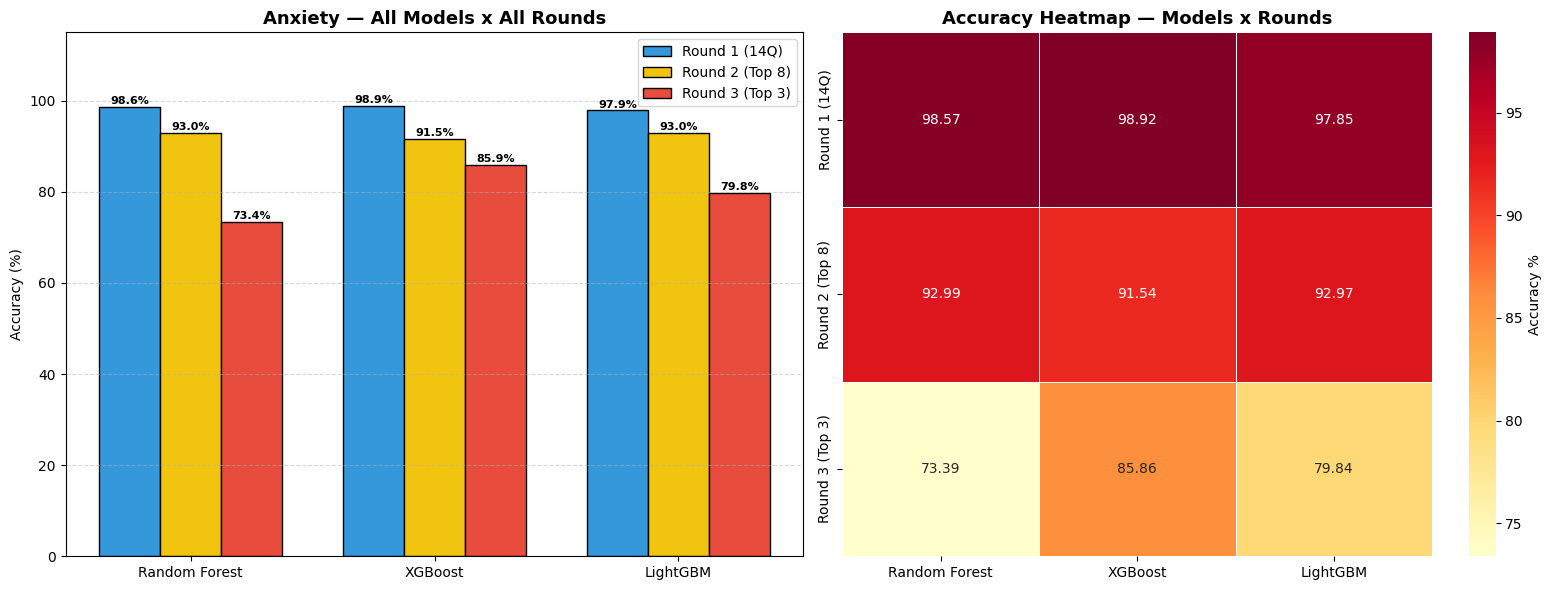

HERO MODEL : XGBoost  |  Round 1 (14Q)  |  98.92%


In [18]:
models = ['Random Forest', 'XGBoost', 'LightGBM']
r1_acc = [acc_rf_r1*100,  acc_xgb_r1*100,  acc_lgbm_r1*100]
r2_acc = [acc_rf_r2*100,  acc_xgb_r2*100,  acc_lgbm_r2*100]
r3_acc = [acc_rf_r3*100,  acc_xgb_r3*100,  acc_lgbm_r3*100]

x     = np.arange(len(models))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grouped Bar Chart
b1 = axes[0].bar(x - width, r1_acc, width, label='Round 1 (14Q)',   color='#3498db', edgecolor='black')
b2 = axes[0].bar(x,         r2_acc, width, label='Round 2 (Top 8)', color='#f1c40f', edgecolor='black')
b3 = axes[0].bar(x + width, r3_acc, width, label='Round 3 (Top 3)', color='#e74c3c', edgecolor='black')

for bars in [b1, b2, b3]:
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                     f'{bar.get_height():.1f}%', ha='center', va='bottom',
                     fontsize=8, fontweight='bold')

axes[0].set_title('Anxiety — All Models x All Rounds', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 115)
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Accuracy Heatmap
heat_data = np.array([r1_acc, r2_acc, r3_acc])
sns.heatmap(heat_data, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=models,
            yticklabels=['Round 1 (14Q)', 'Round 2 (Top 8)', 'Round 3 (Top 3)'],
            ax=axes[1], linewidths=0.5, cbar_kws={'label': 'Accuracy %'})
axes[1].set_title('Accuracy Heatmap — Models x Rounds', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'HERO MODEL : {hero["Model"]}  |  {hero["Round"]}  |  {hero["Accuracy (%)"]:.2f}%')